Salt & Pepper experiment with 2 fates.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from vertax import BilevelOptimizationMethod, BoundedBilevelOptimizer, BoundedMesh, FacePlot, plot_mesh
from vertax.cost import cost_checkerboard
from vertax.energy import energy_bounded

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


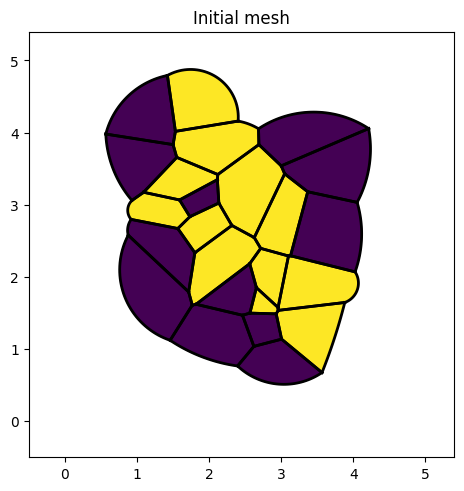

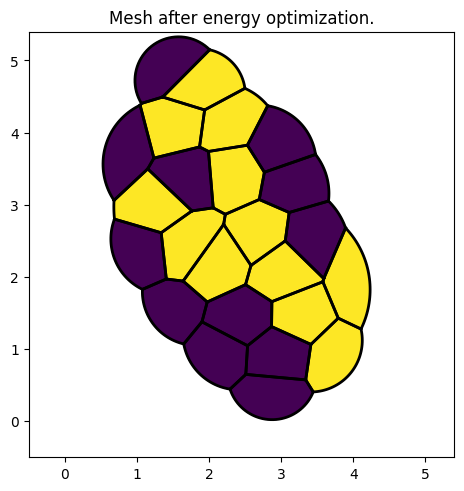

epoch: 0/10000, current cost is 7.940661430358887


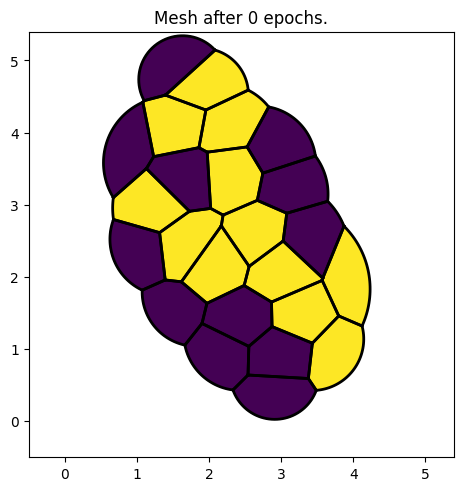

epoch: 1/10000, current cost is 7.996342182159424
epoch: 2/10000, current cost is 7.995800971984863
epoch: 3/10000, current cost is 7.979238986968994
epoch: 4/10000, current cost is 7.958990573883057
epoch: 5/10000, current cost is 7.937660217285156
epoch: 6/10000, current cost is 7.916428089141846
epoch: 7/10000, current cost is 7.89747953414917
epoch: 8/10000, current cost is 7.8808441162109375
epoch: 9/10000, current cost is 7.860296726226807
epoch: 10/10000, current cost is 7.839949607849121
epoch: 11/10000, current cost is 7.819795608520508
epoch: 12/10000, current cost is 7.799833297729492
epoch: 13/10000, current cost is 7.780069351196289
epoch: 14/10000, current cost is 7.760493755340576
epoch: 15/10000, current cost is 7.741110801696777
epoch: 16/10000, current cost is 7.716299057006836
epoch: 17/10000, current cost is 7.697343826293945
epoch: 18/10000, current cost is 7.679113864898682
epoch: 19/10000, current cost is 7.660216808319092
epoch: 20/10000, current cost is 7.64182

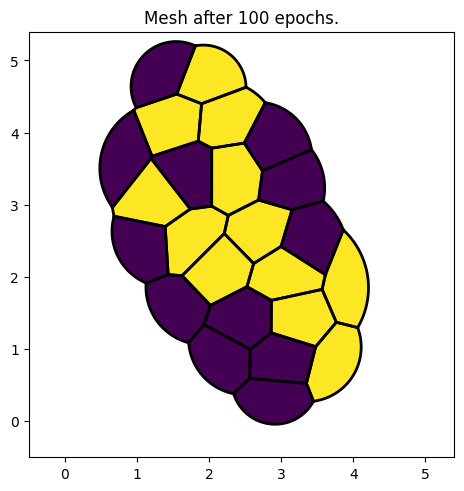

epoch: 101/10000, current cost is 6.608026504516602
epoch: 102/10000, current cost is 6.601663589477539
epoch: 103/10000, current cost is 6.590121746063232
epoch: 104/10000, current cost is 6.5799665451049805
epoch: 105/10000, current cost is 6.578754425048828
epoch: 106/10000, current cost is 6.571136474609375
epoch: 107/10000, current cost is 6.56721830368042
epoch: 108/10000, current cost is 6.558331489562988
epoch: 109/10000, current cost is 6.51862907409668
epoch: 110/10000, current cost is 6.5052924156188965
epoch: 111/10000, current cost is 6.493710994720459
epoch: 112/10000, current cost is 6.482624053955078
epoch: 113/10000, current cost is 6.471708297729492
epoch: 114/10000, current cost is 6.460895538330078
epoch: 115/10000, current cost is 6.450153827667236
epoch: 116/10000, current cost is 6.439484596252441
epoch: 117/10000, current cost is 6.428882122039795


KeyboardInterrupt: 

In [2]:
"""Initial configuration is created randomly."""

# Set mesh geometry
n_cells = 24
L_box = jnp.sqrt(n_cells)
width = float(L_box)
height = float(L_box)

# Create a new mesh
rng = np.random.default_rng(1337)
rng_seed = rng.integers(0, 2 ** 32 - 1)
mesh = BoundedMesh.from_random_seeds(nb_seeds=n_cells, width=width, height=height, random_key=rng_seed)
plot_mesh(mesh, title="Initial mesh", face_plot=FacePlot.FATES, faces_cmap_name="viridis")

# Initialize degrees of freedom
mesh.vertices_params = jnp.asarray([0.0 for _ in range(mesh.nb_vertices)])
key = jax.random.PRNGKey(rng_seed)
mesh.edges_params = jax.random.uniform(key, (mesh.nb_edges,))* 20 - 10
mesh.faces_params = jnp.asarray([0.0 for _ in range(mesh.nb_faces)])

# Set inner optimization hyperparameters
bilevel_optimizer = BoundedBilevelOptimizer()
bilevel_optimizer.inner_solver = optax.sgd(learning_rate=0.01)
bilevel_optimizer.update_T1 = True
bilevel_optimizer.min_dist_T1 = 0.025
bilevel_optimizer.max_nb_iterations = 1000
bilevel_optimizer.tolerance = 1e-6
bilevel_optimizer.patience = 5
bilevel_optimizer.loss_function_inner = energy_bounded

# Perform energy optimization
loss_history = bilevel_optimizer.inner_optimization(mesh)
plot_mesh(mesh, title="Mesh after energy optimization.", face_plot=FacePlot.FATES, faces_cmap_name="viridis")

# Set outer optimization hyperparameters
bilevel_optimizer.outer_solver = optax.adam(learning_rate=0.01, nesterov=True)
bilevel_optimizer.bilevel_optimization_method = BilevelOptimizationMethod.AUTOMATIC_DIFFERENTIATION
bilevel_optimizer.loss_function_outer=cost_checkerboard
epochs = 10000

# Perform bilevel optimization
for epoch in range(epochs + 1):
    cost = cost_checkerboard(mesh.vertices, None, mesh.edges, mesh.faces)
    print(f"epoch: {epoch}/{epochs}, current cost is {cost}")
    loss_history = bilevel_optimizer.bilevel_optimization(mesh)
    if epoch % 100 == 0:
        plot_mesh(mesh, title=f"Mesh after {epoch} epochs.", face_plot=FacePlot.FATES, faces_cmap_name="viridis")